In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../datasets/Teen_Mental_Health_Dataset.csv')

In [4]:
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [5]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [6]:
df.sample(5)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
623,14,male,2.9,Instagram,7.2,2.0,3.96,1.5,medium,9,10,4,0
170,13,female,1.9,TikTok,8.5,0.8,3.33,1.3,medium,5,1,3,0
684,19,male,2.4,Both,7.5,1.8,2.35,1.4,low,3,8,6,0
827,14,female,3.5,Instagram,4.6,0.7,2.74,1.0,low,2,7,8,0
1091,13,male,3.5,Both,6.8,2.3,2.28,1.0,low,7,2,6,0


In [ ]:
df.info()
#No null values, 12 columns and their dtypes

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


In [ ]:
df.describe()
#Lot's of insight from this, age range is 13-19 with mean 16, similar for all numeric columns

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [ ]:
df.shape
#1200 rows, 13 columns

(1200, 13)

In [ ]:
df.duplicated().sum()
#No duplicate values

np.int64(0)

In [ ]:
df.corr(numeric_only=True)
#Lot's of info from this, postive corr between depression, stress, anxiety. Showing insights between specific columns after the table.

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
age,1.000000,-0.006635,0.001530,0.075612,-0.013973,0.011086,-0.031208,0.026363,0.038265,0.010973
daily_social_media_hours,-0.006635,1.000000,-0.009472,0.035777,0.013179,0.025546,0.030698,0.027835,-0.024964,0.175201
sleep_hours,0.001530,-0.009472,1.000000,0.010235,0.021866,0.012701,-0.010979,-0.011879,-0.054838,-0.190630
screen_time_before_sleep,0.075612,0.035777,0.010235,1.000000,-0.034715,-0.026450,-0.008650,-0.010344,0.028884,-0.016502
academic_performance,-0.013973,0.013179,0.021866,-0.034715,1.000000,0.023312,-0.000600,-0.064379,0.029354,0.001441
physical_activity,0.011086,0.025546,0.012701,-0.026450,0.023312,1.000000,0.012159,-0.022233,0.026200,-0.017598
stress_level,-0.031208,0.030698,-0.010979,-0.008650,-0.000600,0.012159,1.000000,0.015811,-0.000129,0.170474
anxiety_level,0.026363,0.027835,-0.011879,-0.010344,-0.064379,-0.022233,0.015811,1.000000,0.031154,0.169566
addiction_level,0.038265,-0.024964,-0.054838,0.028884,0.029354,0.026200,-0.000129,0.031154,1.000000,-0.013952
depression_label,0.010973,0.175201,-0.190630,-0.016502,0.001441,-0.017598,0.170474,0.169566,-0.013952,1.000000


In [ ]:
df.corr(numeric_only=True)['physical_activity']
#Negative corr with screen before sleep, anxiety and depression. Possitive with academic performance.

age                         0.011086
daily_social_media_hours    0.025546
sleep_hours                 0.012701
screen_time_before_sleep   -0.026450
academic_performance        0.023312
physical_activity           1.000000
stress_level                0.012159
anxiety_level              -0.022233
addiction_level             0.026200
depression_label           -0.017598
Name: physical_activity, dtype: float64

In [ ]:
df.corr(numeric_only=True)['sleep_hours']
#Strong negative corr with depression, also with anxiety,addiction,etc. Showing the importance of sleep.

age                         0.001530
daily_social_media_hours   -0.009472
sleep_hours                 1.000000
screen_time_before_sleep    0.010235
academic_performance        0.021866
physical_activity           0.012701
stress_level               -0.010979
anxiety_level              -0.011879
addiction_level            -0.054838
depression_label           -0.190630
Name: sleep_hours, dtype: float64

In [39]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


<Axes: xlabel='age', ylabel='count'>

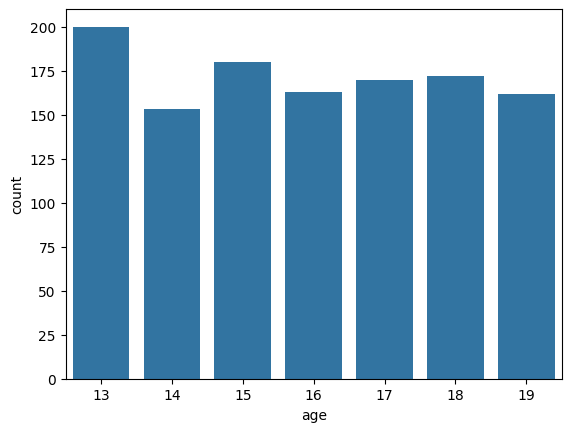

In [ ]:
sns.countplot(x=df['age'])
#Shows data is fairly representing different ages

<Axes: xlabel='gender', ylabel='count'>

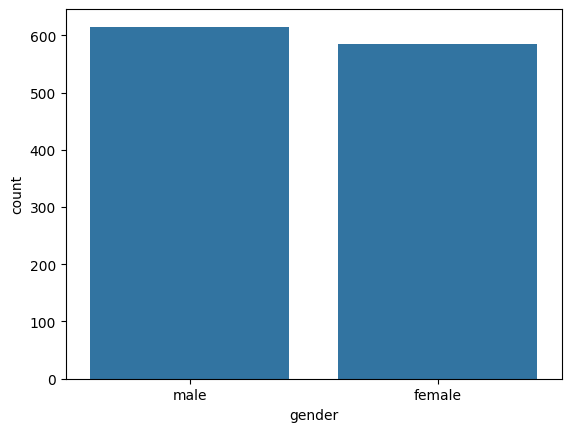

In [ ]:
sns.countplot(x=df['gender'])
#Data is fairly representing both genders

In [38]:
df['gender'].value_counts()

gender
male      615
female    585
Name: count, dtype: int64

<Axes: xlabel='platform_usage', ylabel='count'>

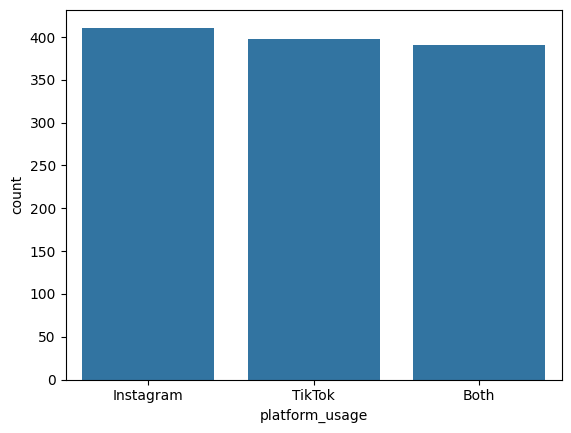

In [40]:
sns.countplot(x=df['platform_usage'])

<Axes: xlabel='social_interaction_level', ylabel='count'>

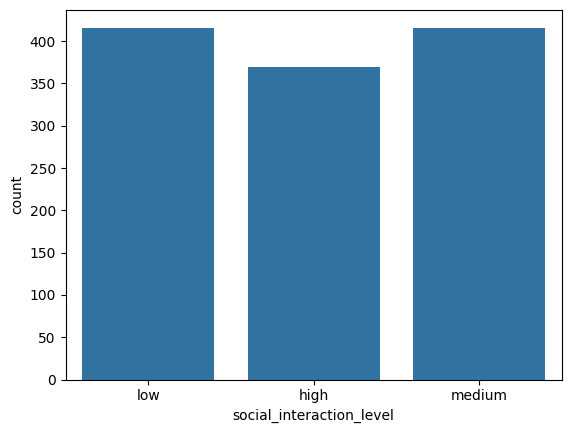

In [41]:
sns.countplot(x=df['social_interaction_level'])

<Axes: xlabel='stress_level', ylabel='Count'>

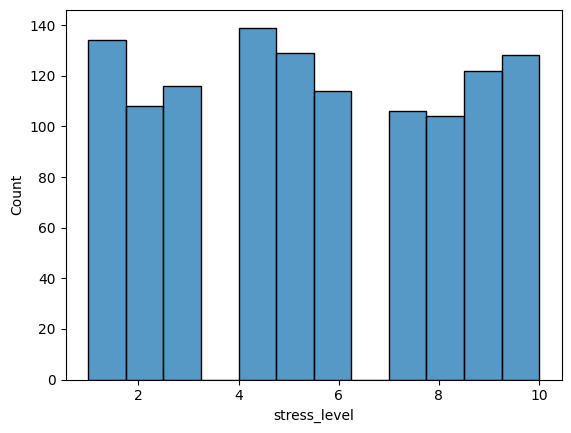

In [92]:
sns.histplot(x=df['stress_level'])

<Axes: xlabel='anxiety_level', ylabel='Count'>

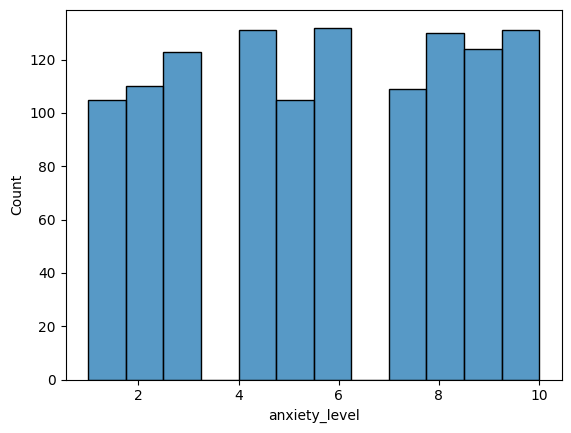

In [91]:
sns.histplot(x=df['anxiety_level'])

<Axes: xlabel='addiction_level', ylabel='count'>

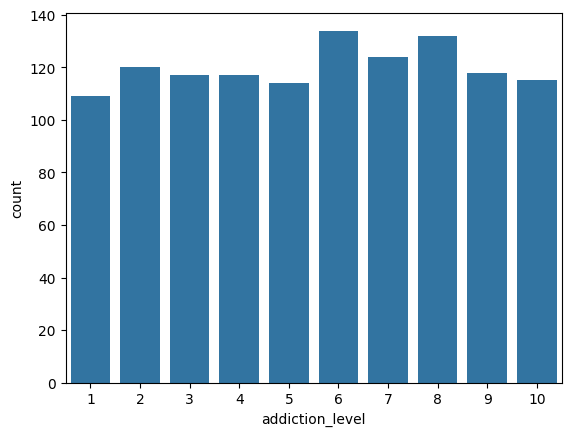

In [93]:
sns.countplot(x=df['addiction_level'])

<Axes: >

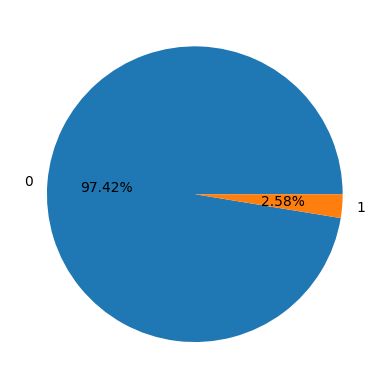

In [ ]:
df['depression_label'].value_counts().plot(kind='pie',autopct='%.2f%%')
#Shows that 2.58% of teenagers in dataset are depressed

<Axes: >

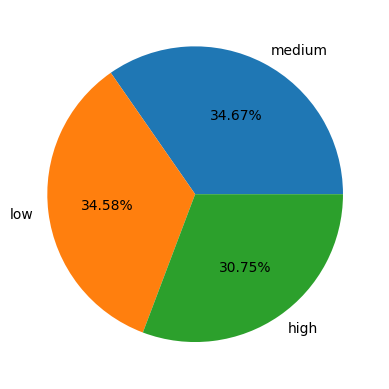

In [106]:
df['social_interaction_level'].value_counts().plot(kind='pie',autopct='%.2f%%')

In [74]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


<Axes: xlabel='sleep_hours'>

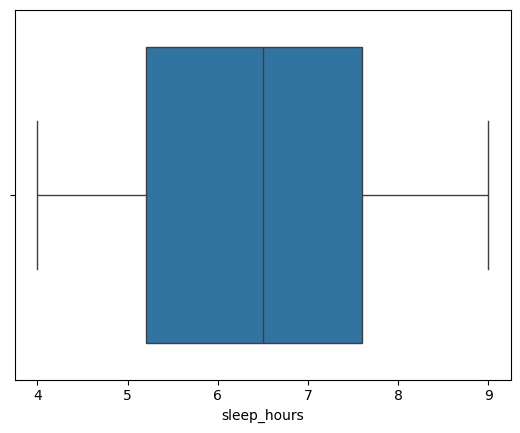

In [96]:
sns.boxplot(x=df['sleep_hours'])

<Axes: xlabel='screen_time_before_sleep', ylabel='Count'>

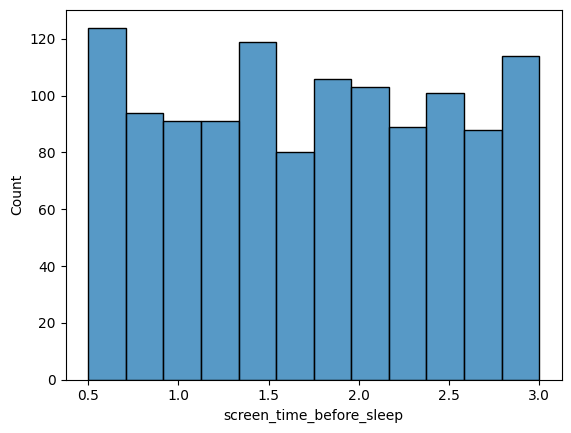

In [101]:
sns.histplot(df['screen_time_before_sleep'])

<Axes: xlabel='daily_social_media_hours'>

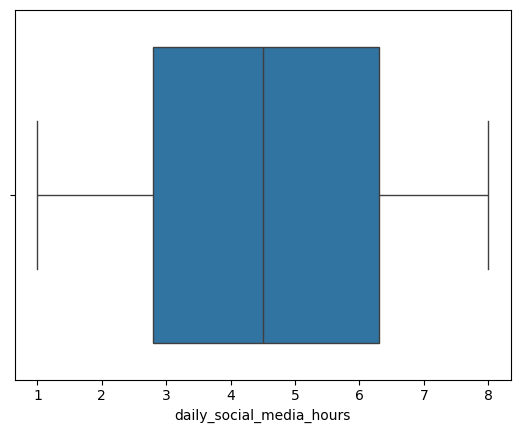

In [98]:
sns.boxplot(x=df['daily_social_media_hours'])

<Axes: xlabel='academic_performance'>

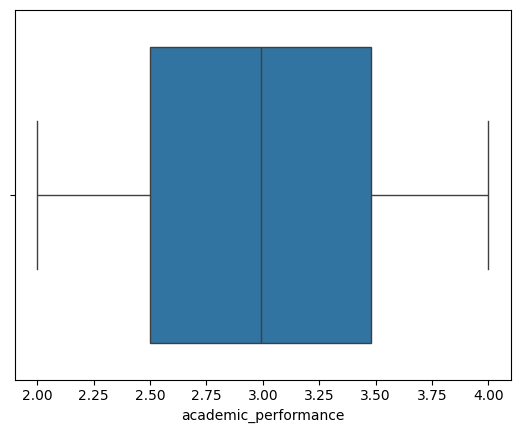

In [99]:
sns.boxplot(x=df['academic_performance'])

In [100]:
df['academic_performance'].describe()

count    1200.000000
mean        2.990383
std         0.576758
min         2.000000
25%         2.500000
50%         2.990000
75%         3.480000
max         4.000000
Name: academic_performance, dtype: float64

<Axes: xlabel='physical_activity', ylabel='Count'>

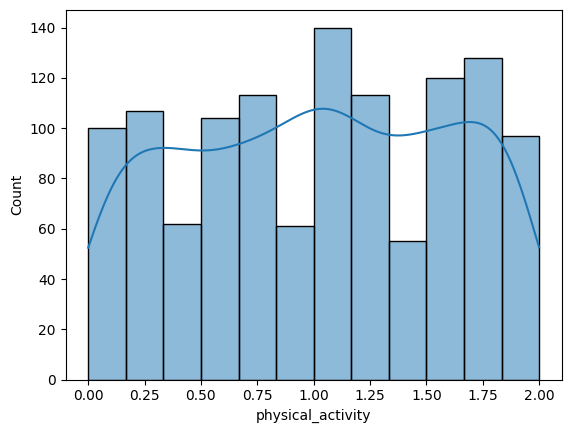

In [103]:
sns.histplot(df['physical_activity'],kde=True)